In [1]:
import Pkg

Pkg.activate(normpath(joinpath(@__DIR__, "..", "..")))

using LongitudinalTomography

  Activating project at `~/Desktop/longitudinal_dynamics`


In [2]:
# Import packages
using FileIO
using ImageIO
using Colors
using Statistics
using CairoMakie
using LongitudinalTomography
using Printf

# Define the global theme for regular text and mathematical equations
set_theme!(Theme(
    font = "StixGeneral",
    mathfont = "StixGeneral",
    
    # Force individual elements to inherit it correctly
    titlefont = "StixGeneral",
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral"
))


# CairoMakie.activate!()


In [3]:
set_theme!(
    font = "StixGeneral",
    mathfont = "StixGeneral",
    fontsize = 28,
    Axis = (
        titlefont = "StixGeneral",
        xlabelfont = "StixGeneral",
        ylabelfont = "StixGeneral",
        xticklabelfont = "StixGeneral",
        yticklabelfont = "StixGeneral",
        xticklabelsize = 24,
        yticklabelsize = 24,
    ),
    Legend = (
        labelfont = "StixGeneral",
        titlefont = "StixGeneral",
        labelsize = 24,
    ),
    Colorbar = (
        labelfont = "StixGeneral",
        ticklabelfont = "StixGeneral",
        titlefont = "StixGeneral",
        labelsize = 24,       # Size of the side label text
        ticklabelsize = 24,   # Size of the numeric scale ticks
    )
)


In [4]:
# Create machine to simulate
const PROTON_MASS_EV = 938.2720813e6
const C_LIGHT_M_PER_S = 299_792_458.0

kinetic_energy_eV = 8.0e9
total_energy_eV = kinetic_energy_eV + PROTON_MASS_EV
gamma_s = total_energy_eV / PROTON_MASS_EV
beta_s = sqrt(1 - 1 / gamma_s^2)

machine = SingleRFMachine(
    harmonic=588,
    f_rev_hz=89.8e3,
    eta0=-8.8e-3,
    beta_s=beta_s,
    E_s_eV=total_energy_eV,
    rf_kick_eV=80.0e3,
    phi_s=0.0,
    delta_t_s=0.0,
)

@printf("Q_s                  = %.7f\n", synchrotron_tune(machine))
@printf("synchrotron period   = %.2f turns\n", synchrotron_period_turns(machine))

Q_s                  = 0.0027300
synchrotron period   = 366.30 turns


In [5]:
# Observation grid and soft RWCM bins

turns = collect(0.0:5.0:500.0)

half_width_s = bucket_half_width_s(machine)
n_time_bins = 75
time_bin_centers_s = collect(range(
    machine.delta_t_s - half_width_s,
    machine.delta_t_s + half_width_s;
    length=n_time_bins,
))
time_bin_spacing_s = time_bin_centers_s[2] - time_bin_centers_s[1]
soft_sigma_s = 0.75 * time_bin_spacing_s

validation_turn_indices = collect(5:5:length(turns))
training_turn_indices = setdiff(
    collect(eachindex(turns)),
    validation_turn_indices,
)

@printf("bucket half-width      = %.3f ns\n", bucket_half_width_s(machine) * 1e9)
@printf("profiles              = %d\n", length(turns))
@printf("training profiles     = %d\n", length(training_turn_indices))
@printf("validation profiles   = %d\n", length(validation_turn_indices))
@printf("time bins             = %d\n", n_time_bins)

bucket half-width      = 9.469 ns
profiles              = 101
training profiles     = 81
validation profiles   = 20
time bins             = 75


In [6]:
# ## Grid cells inside the separatrix
#
# Cell centers are used instead of grid edges. `energy_margin` keeps the active
# cells away from the elliptic `k -> 1` limit at the separatrix.

grid = separatrix_grid(
    n_theta=101,
    n_P=101,
    energy_margin=2e-3,
    theta_limits=(-pi, pi),
    P_limits=(-2.0, 2.0),
)

theta_separatrix = range(-pi, pi; length=1000)
P_separatrix = 2 .* cos.(theta_separatrix ./ 2)

@assert all(inside_separatrix(
    grid.theta_nodes,
    grid.P_nodes;
    margin=grid.energy_margin,
))

@printf("active grid cells     = %d\n", length(grid))
@printf("TV neighbor pairs     = %d\n", length(grid.edge_from))

active grid cells     = 6487
TV neighbor pairs     = 12774


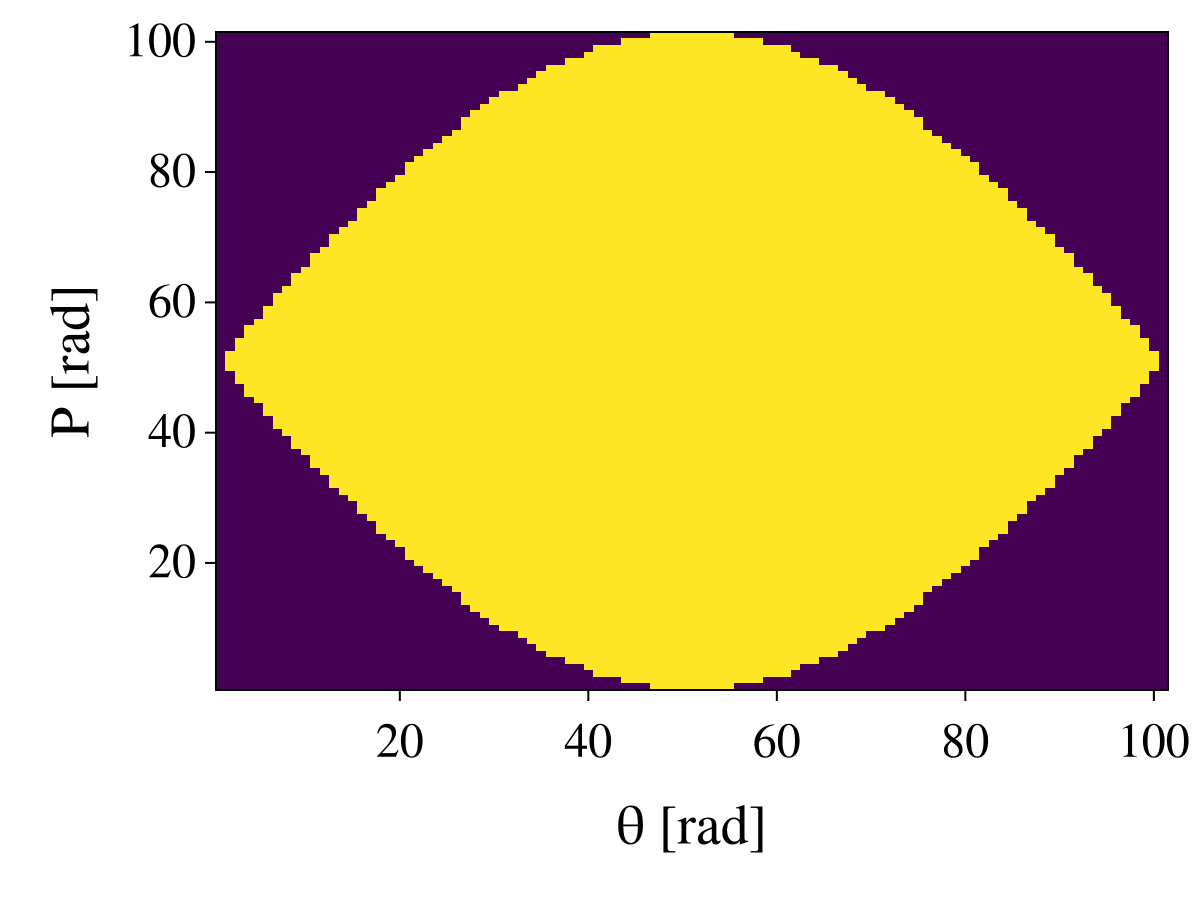

In [7]:
heatmap(grid.mask',
    axis=(xlabel="θ [rad]", ylabel="P [rad]"),
    colormap=:viridis,
    colorrange=(0, 1),
)


In [8]:
# ## Precompute the tomographic response matrix
#
# If `w` contains the initial cell masses, the complete predicted cascade is
#
#     y_hat = A*w
#
# followed only by a reshape. Exact elliptic transport is therefore evaluated
# once rather than at every optimization step.

response = build_response_matrix(
    grid,
    turns,
    machine,
    time_bin_centers_s;
    sigma=soft_sigma_s,
)

response_megabytes = Base.summarysize(response.matrix) / 1024^2

@printf(
    "response dimensions   = %d x %d\n",
    size(response.matrix, 1),
    size(response.matrix, 2),
)
@printf("response memory       = %.1f MiB\n", response_megabytes)

# Every response column deposits unit charge at every turn.
response_tensor = reshape(
    response.matrix,
    length(turns),
    n_time_bins,
    length(grid),
)
response_charge_error = maximum(abs.(
    sum(response_tensor; dims=2) .- 1,
))
@printf("response charge error = %.3e\n", response_charge_error)

response dimensions   = 7575 x 6487
response memory       = 374.9 MiB
response charge error = 7.772e-16


In [9]:
# Initiate synthetic ground truth distribution from digitized distributions

figure_path = joinpath(
    "/Users/gonza839/Desktop/longitudinal_dynamics/julia_notebooks/singleRF_grid_tomo/",
    "digitized_distributions",
    "rob2.png",
)

source_image = load(figure_path)

# Julia uses row, column indexing.
left_panel_rows = 53:706
left_panel_cols = 339:952

right_panel_rows = 53:706
right_panel_cols = 976:1589

976:1589

In [10]:
"""
Convert one plot pixel into an approximate relative density.

The conversion is based on the monotonic color progression in the supplied
figure. It suppresses grayscale pixels, including the black separatrix and
white background.
"""
function pixel_relative_density(
    pixel;
    chroma_min=0.20,
    gamma=1.0,
)
    rgb = RGB{Float64}(pixel)

    channels = (
        Float64(red(rgb)),
        Float64(green(rgb)),
        Float64(blue(rgb)),
    )

    chroma = maximum(channels) - minimum(channels)

    # Remove white background, black curves, axes, labels, and gray pixels.
    chroma < chroma_min && return 0.0

    hsv = convert(HSV, rgb)
    hue = mod(Float64(hsv.h), 360.0)
    value = maximum(channels)

    # Dark violet/blue part of the palette: use brightness to distinguish
    # the lowest density levels, whose hue is nearly constant.
    relative_density = if hue > 300.0
        1.0
    elseif hue >= 235.0
        0.02 + 0.20 * clamp(
            (value - 0.45) / 0.53,
            0.0,
            1.0,
        )
    else
        # Blue -> cyan -> green -> yellow -> orange/red.
        0.22 + 0.78 * clamp(
            (235.0 - hue) / (235.0 - 12.0),
            0.0,
            1.0,
        )
    end

    return relative_density^gamma
end


function extract_density_panel(
    image,
    rows,
    columns;
    chroma_min=0.20,
    gamma=1.0,
)
    panel = image[rows, columns]

    return map(panel) do pixel
        pixel_relative_density(
            pixel;
            chroma_min=chroma_min,
            gamma=gamma,
        )
    end
end


left_density_map = extract_density_panel(
    source_image,
    left_panel_rows,
    left_panel_cols;
    gamma=1.0,
)

right_density_map = extract_density_panel(
    source_image,
    right_panel_rows,
    right_panel_cols;
    gamma=1.0,
)

654×614 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

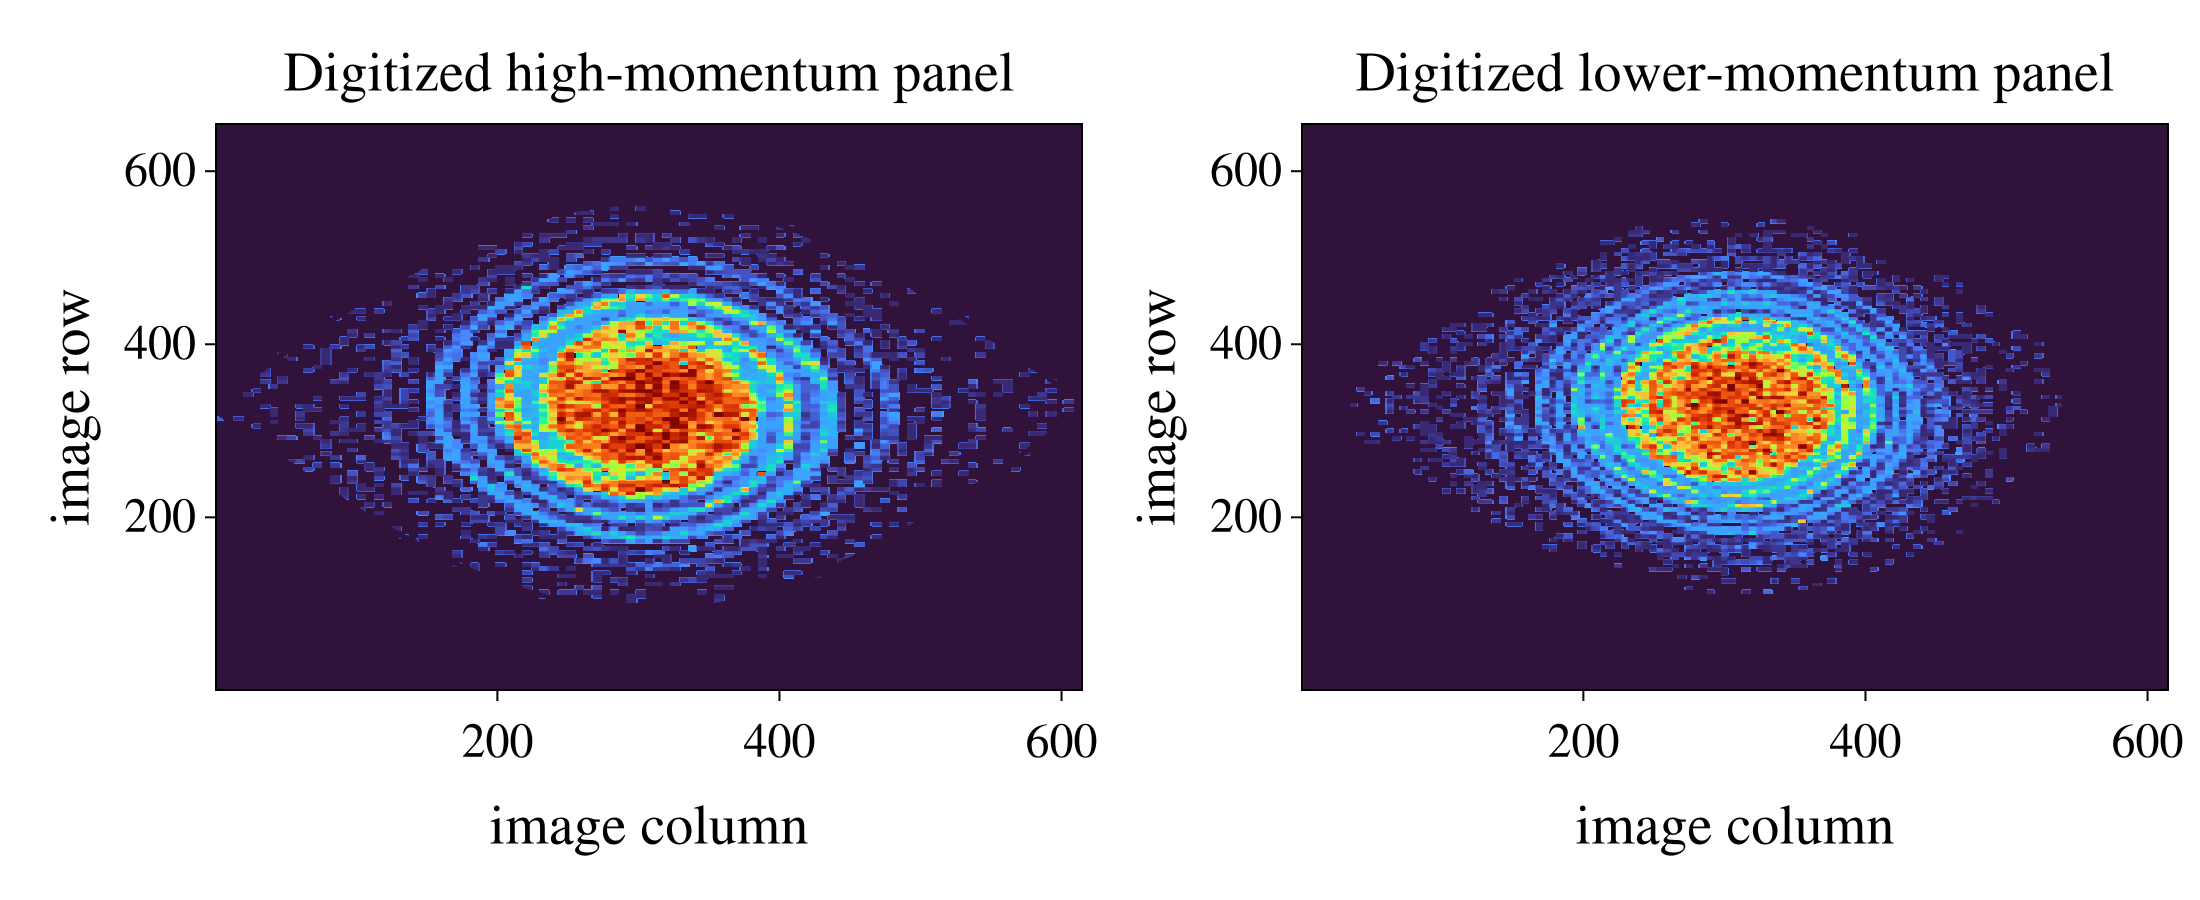

CairoMakie.Screen{IMAGE}


In [11]:
density_figure = Figure(size=(1100, 450))

left_axis = Axis(
    density_figure[1, 1];
    title="Digitized high-momentum panel",
    xlabel="image column",
    ylabel="image row",
)
heatmap!(left_axis, reverse(permutedims(left_density_map),dims=2); colormap=:turbo)

right_axis = Axis(
    density_figure[1, 2];
    title="Digitized lower-momentum panel",
    xlabel="image column",
    ylabel="image row",
)
heatmap!(right_axis, reverse(permutedims(right_density_map),dims=2); colormap=:turbo)

display(density_figure)

In [12]:
function local_physical_coordinates(
    grid,
    machine;
    flip_z=false,
    flip_delta=false,
)
    # Remove delta_t_s because the image is centered on the local
    # synchronous particle of each bucket family.
    delta_t_local =
        delta_t_from_theta(grid.theta_nodes, machine) .-
        machine.delta_t_s

    z_nodes =
        -machine.beta_s * C_LIGHT_M_PER_S .* delta_t_local

    delta_nodes = delta_p_over_p0_from_delta_E(
        delta_energy_from_P(grid.P_nodes, machine),
        machine,
    )

    flip_z && (z_nodes = -z_nodes)
    flip_delta && (delta_nodes = -delta_nodes)

    return z_nodes, delta_nodes
end


function local_physical_axes(grid, machine)
    delta_t_axis =
        delta_t_from_theta(grid.theta_axis, machine) .-
        machine.delta_t_s

    z_axis =
        -machine.beta_s * C_LIGHT_M_PER_S .* delta_t_axis

    delta_axis = delta_p_over_p0_from_delta_E(
        delta_energy_from_P(grid.P_axis, machine),
        machine,
    )

    return z_axis, delta_axis
end


"""
Map a digitized panel onto the active cells of a PhaseSpaceGrid.

The result is normalized to unit mass. Absolute bunch charge is assigned later
from BucketSpec.charge_fraction.
"""
function digitize_panel_on_grid(
    density_map,
    grid,
    machine;
    z_limits=(-2.8, 2.8),
    delta_limits=(-1.5e-3, 1.5e-3),
    cell_fraction=0.85,
    flip_z=false,
    flip_delta=false,
)
    n_rows, n_columns = size(density_map)

    z_nodes, delta_nodes = local_physical_coordinates(
        grid,
        machine;
        flip_z=flip_z,
        flip_delta=flip_delta,
    )

    z_axis, delta_axis = local_physical_axes(grid, machine)

    delta_z_cell = median(abs.(diff(z_axis)))
    delta_delta_cell = median(abs.(diff(delta_axis)))

    z_min, z_max = z_limits
    delta_min, delta_max = delta_limits

    column_radius = max(
        0,
        round(
            Int,
            0.5 * cell_fraction *
            delta_z_cell / (z_max - z_min) *
            (n_columns - 1),
        ),
    )

    row_radius = max(
        0,
        round(
            Int,
            0.5 * cell_fraction *
            delta_delta_cell / (delta_max - delta_min) *
            (n_rows - 1),
        ),
    )

    raw_weights = zeros(Float64, length(grid))

    for node_index in eachindex(grid.theta_nodes)
        z = z_nodes[node_index]
        delta = delta_nodes[node_index]

        if !(z_min <= z <= z_max &&
             delta_min <= delta <= delta_max)
            continue
        end

        column = round(
            Int,
            1 + (z - z_min) / (z_max - z_min) * (n_columns - 1),
        )

        # Image rows increase downward, whereas delta increases upward.
        row = round(
            Int,
            1 + (delta_max - delta) /
                (delta_max - delta_min) * (n_rows - 1),
        )

        first_column = clamp(column - column_radius, 1, n_columns)
        last_column  = clamp(column + column_radius, 1, n_columns)
        first_row    = clamp(row - row_radius, 1, n_rows)
        last_row     = clamp(row + row_radius, 1, n_rows)

        raw_weights[node_index] = sum(
            @view density_map[
                first_row:last_row,
                first_column:last_column,
            ]
        )
    end

    total_mass = sum(raw_weights)

    total_mass > 0 || error(
        "No colored density was mapped onto the grid. " *
        "Check the crop, physical limits, or coordinate signs.",
    )

    return (
        weights=raw_weights ./ total_mass,
        raw_weights=raw_weights,
        z_nodes=z_nodes,
        delta_nodes=delta_nodes,
    )
end

digitize_panel_on_grid

In [13]:
digitized_rf1 = digitize_panel_on_grid(
    left_density_map,
    response.grid,
    machine;
    z_limits=(-2.8, 2.8),
    delta_limits=(-1.5e-3, 1.5e-3),
)

digitized_rf2 = digitize_panel_on_grid(
    right_density_map,
    response.grid,
    machine;
    z_limits=(-2.8, 2.8),
    delta_limits=(-1.5e-3, 1.5e-3),
)

@printf("RF1 local mass = %.12f\n", sum(digitized_rf1.weights))
@printf("RF2 local mass = %.12f\n", sum(digitized_rf2.weights))

RF1 local mass = 1.000000000000
RF2 local mass = 1.000000000000


In [14]:
function digitized_single_rf_weights(
    response,
    rf_local_weights;
    normalize_total=false,
)
    n_grid_cells = length(response.grid)
    n_response_columns = size(response.matrix, 2)

    length(rf_local_weights) == n_grid_cells ||
        throw(DimensionMismatch(
            "Expected $n_grid_cells RF weights, " *
            "but received $(length(rf_local_weights)).",
        ))

    n_response_columns == n_grid_cells ||
        throw(DimensionMismatch(
            "Response has $n_response_columns columns, " *
            "but its grid contains $n_grid_cells active cells.",
        ))

    weights = Float64.(rf_local_weights)

    all(isfinite, weights) ||
        throw(ArgumentError("RF weights must all be finite."))

    all(weight -> weight >= 0, weights) ||
        throw(ArgumentError("RF weights must be nonnegative."))

    if normalize_total
        total_weight = sum(weights)

        total_weight > 0 ||
            throw(ArgumentError(
                "Cannot normalize weights with zero total mass.",
            ))

        weights ./= total_weight
    end

    return weights
end

function digitized_slip_stacked_weights(
    response,
    rf1_local_weights,
    rf2_local_weights;
    normalize_total=false,
)
    length(rf1_local_weights) == length(response.rf1_grid) ||
        throw(DimensionMismatch("Incorrect RF1 local-weight length."))

    length(rf2_local_weights) == length(response.rf2_grid) ||
        throw(DimensionMismatch("Incorrect RF2 local-weight length."))

    weights = zeros(Float64, size(response.matrix, 2))

    for block_index in eachindex(response.bucket_specs)
        spec = response.bucket_specs[block_index]
        block_range = response.block_ranges[block_index]

        local_shape = if spec.family == :rf1
            rf1_local_weights
        else
            rf2_local_weights
        end

        weights[block_range] .=
            spec.charge_fraction .* local_shape
    end

    if normalize_total
        weights ./= sum(weights)
    end

    return weights
end

digitized_slip_stacked_weights (generic function with 1 method)

In [15]:
target_weights = digitized_single_rf_weights(
    response,
    digitized_rf1.weights;
    normalize_total=true,
)

target_profiles = profiles_from_response(
    response,
    target_weights;
    normalize=false,
)

@printf("Target charge = %.12f\n", sum(target_weights))
@printf(
    "Profile charge error = %.3e\n",
    maximum(abs.(
        sum(target_profiles; dims=2) .- sum(target_weights)
    )),
)

Target charge = 1.000000000000
Profile charge error = 1.443e-15


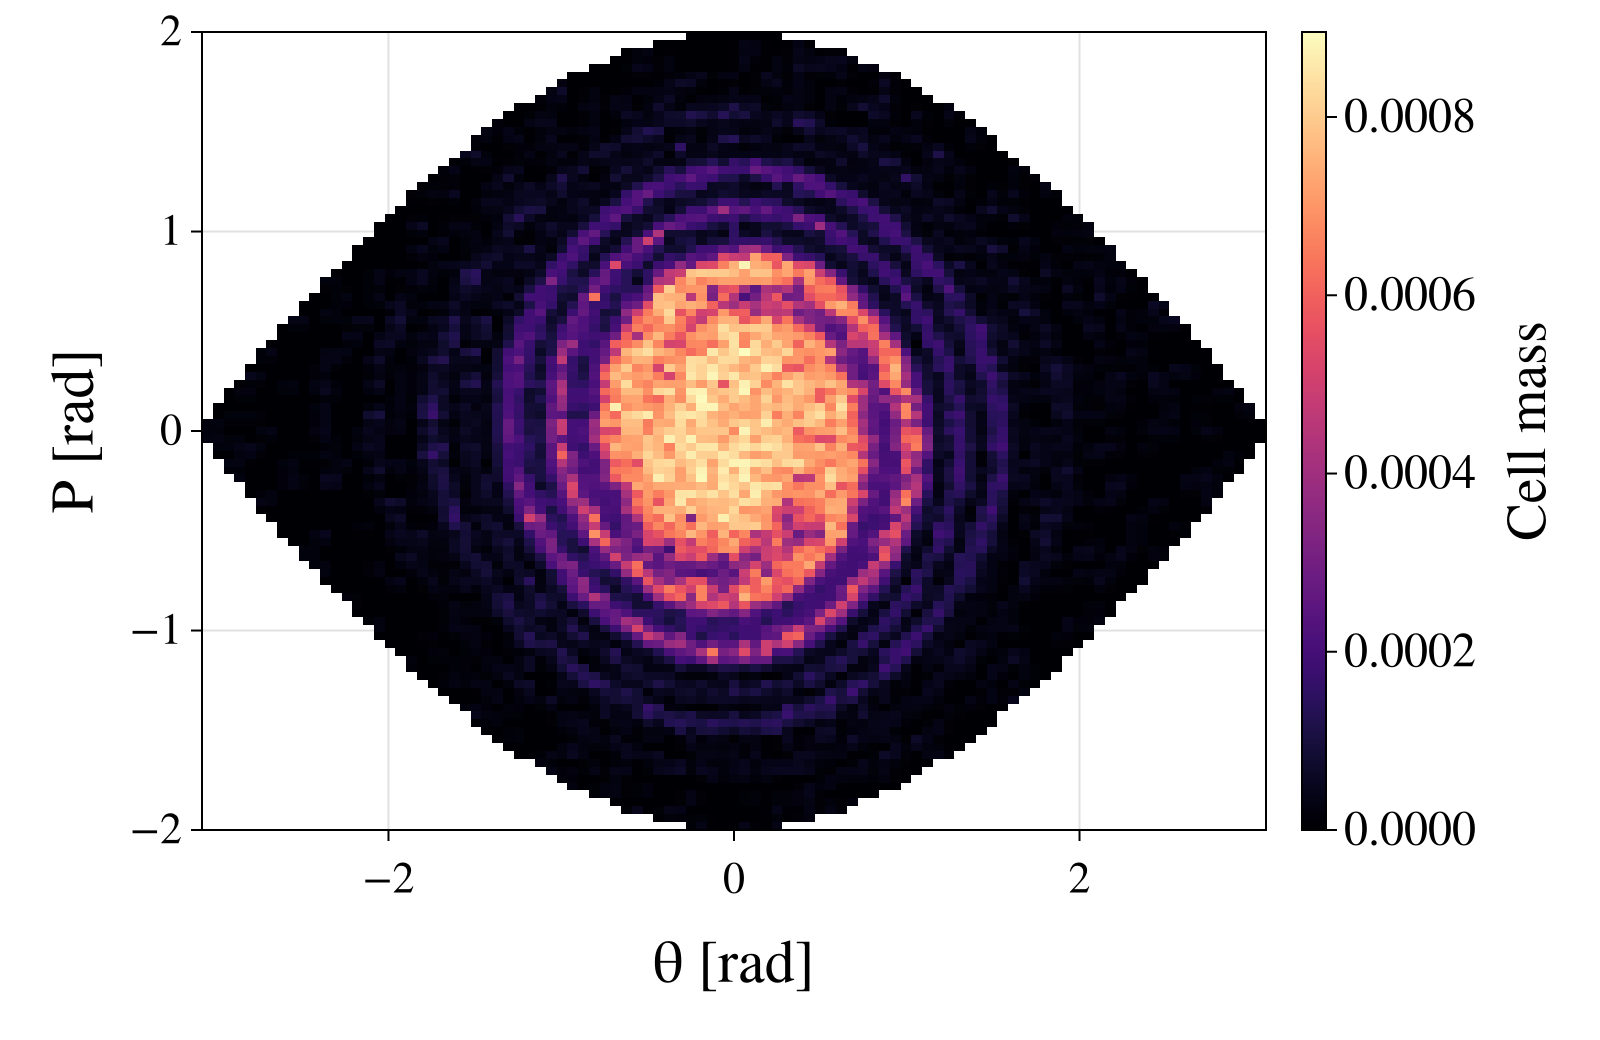

CairoMakie.Screen{IMAGE}


In [16]:
# Plot the target distribution and profiles
weight_figure = Figure(size=(800, 520))
weight_axis = Axis(
    weight_figure[1,1];
    xlabel="θ [rad]",
    ylabel="P [rad]",
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",

    xlabelsize = 30,
    ylabelsize = 30,


    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)

heat=heatmap!(
    weight_axis,
    grid.theta_nodes,
    grid.P_nodes,
    target_weights;
    colormap=:magma,
    colorrange=(0, maximum(target_weights)),
)

# Change weight_axis to weight_figure[1, 2]
Colorbar(
    weight_figure[1, 2],
    heat; 
    label = "Cell mass",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
)


display(weight_figure)

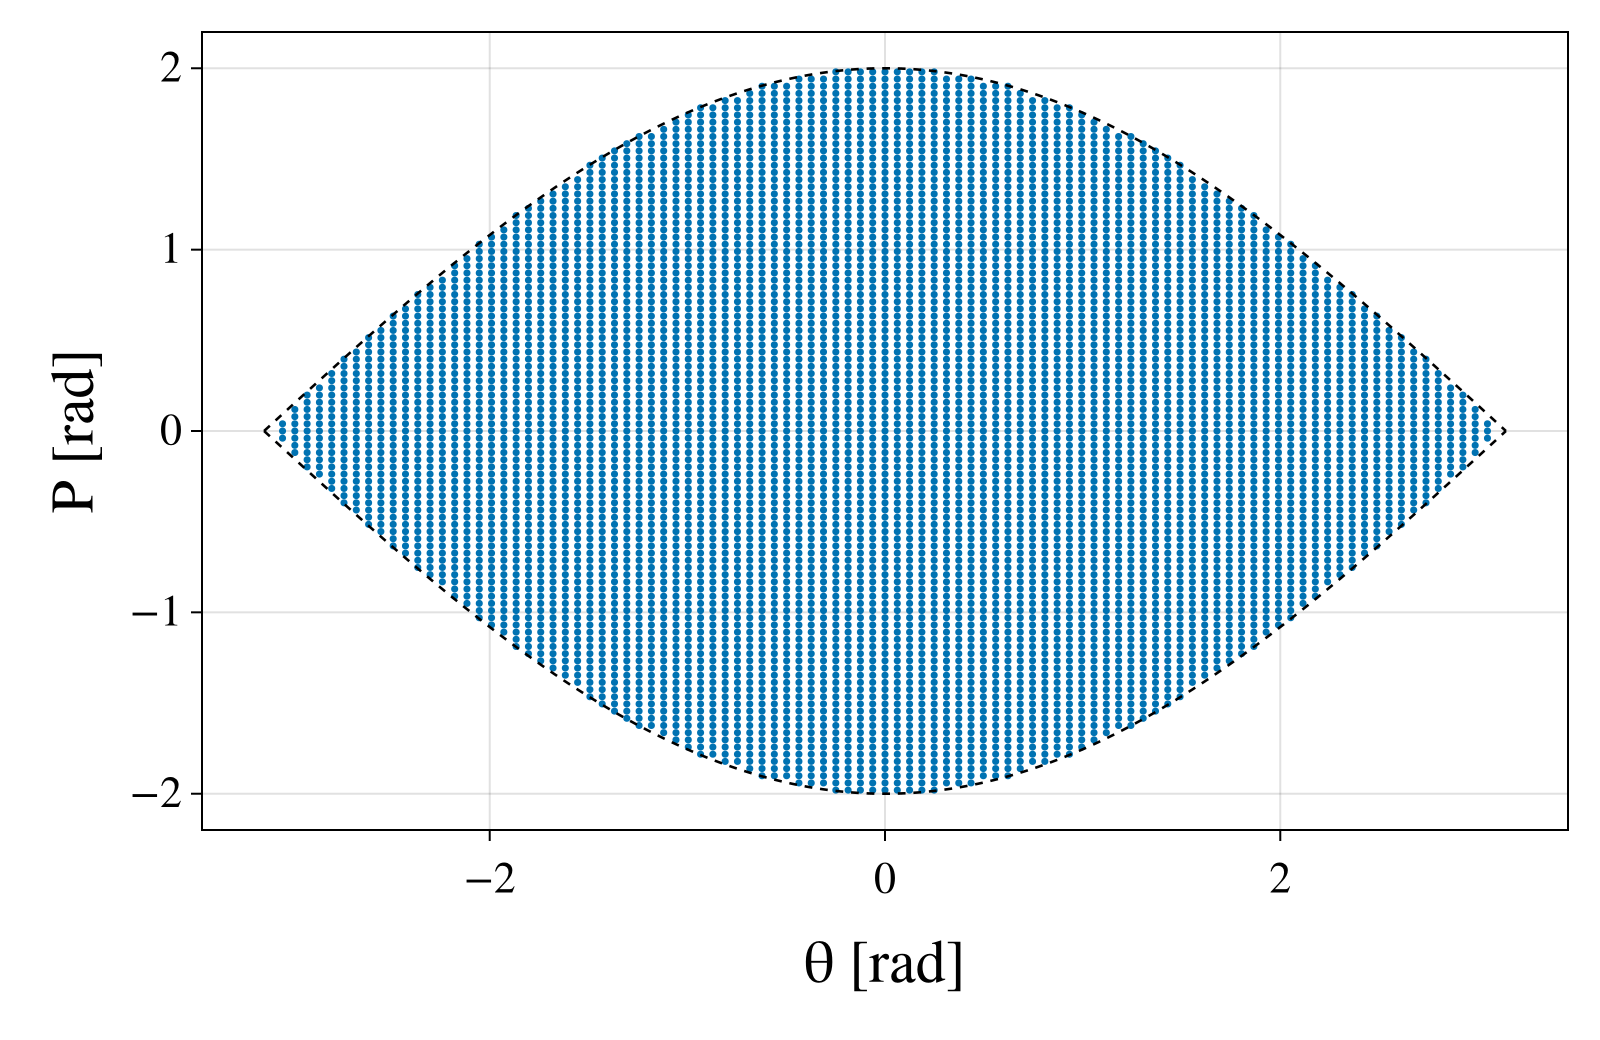

CairoMakie.Screen{IMAGE}


In [17]:
grid_figure = Figure(size=(800, 520))
grid_axis = Axis(
    grid_figure[1,1];
    xlabel="θ [rad]",
    ylabel="P [rad]",
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",

    xlabelsize = 30,
    ylabelsize = 30,


    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)

scatter!(
    grid_axis,
    grid.theta_nodes,
    grid.P_nodes,
    markersize=5,
)

lines!(
    grid_axis,
    theta_separatrix,
    P_separatrix;
    color=:black,
    linestyle=:dash,
    linewidth=1.3,
)

lines!(
    grid_axis,
    theta_separatrix,
    -P_separatrix;
    color=:black,
    linestyle=:dash,
    linewidth=1.3,
)
display(grid_figure)

In [18]:
# ## Reconstruct the unknown cell masses
#
# The initial logits are zero, corresponding to a uniform density over active
# cells. The fit uses only the training turns. The regularizers are deliberately
# weak so that the profile data dominate this first demonstration.

# Initialize the reconstruction with uniform weights
initial_logits = zeros(length(grid))
initial_profiles = profiles_from_response(
    response,
    grid_weights_from_logits(initial_logits);
    normalize=false,
)
initial_training_mse = profile_mse(
    initial_profiles,
    target_profiles;
    turn_indices=training_turn_indices,
)

# Reconstruct the grid weights and profiles
result = reconstruct_grid(
    response,
    target_profiles;
    iterations=2000,
    learning_rate=0.08,
    initial_logits=initial_logits,
    train_turn_indices=training_turn_indices,
    lambda_tv=1e-2,
    lambda_entropy=1e-6,
)

reconstructed_weights = result.weights
reconstructed_profiles = result.profiles

final_training_mse = profile_mse(
    reconstructed_profiles,
    target_profiles;
    turn_indices=training_turn_indices,
)
validation_mse = profile_mse(
    reconstructed_profiles,
    target_profiles;
    turn_indices=validation_turn_indices,
)
phase_space_l1 = sum(abs.(reconstructed_weights .- target_weights))

@printf("initial training MSE  = %.6e\n", initial_training_mse)
@printf("final training MSE    = %.6e\n", final_training_mse)
@printf("held-out-turn MSE     = %.6e\n", validation_mse)
@printf("phase-space L1 error  = %.6e\n", phase_space_l1)
@printf("reconstructed charge = %.12f\n", sum(reconstructed_weights))

initial training MSE  = 1.536286e-04
final training MSE    = 5.425822e-08
held-out-turn MSE     = 6.180797e-08
phase-space L1 error  = 2.111394e-01
reconstructed charge = 1.000000000000


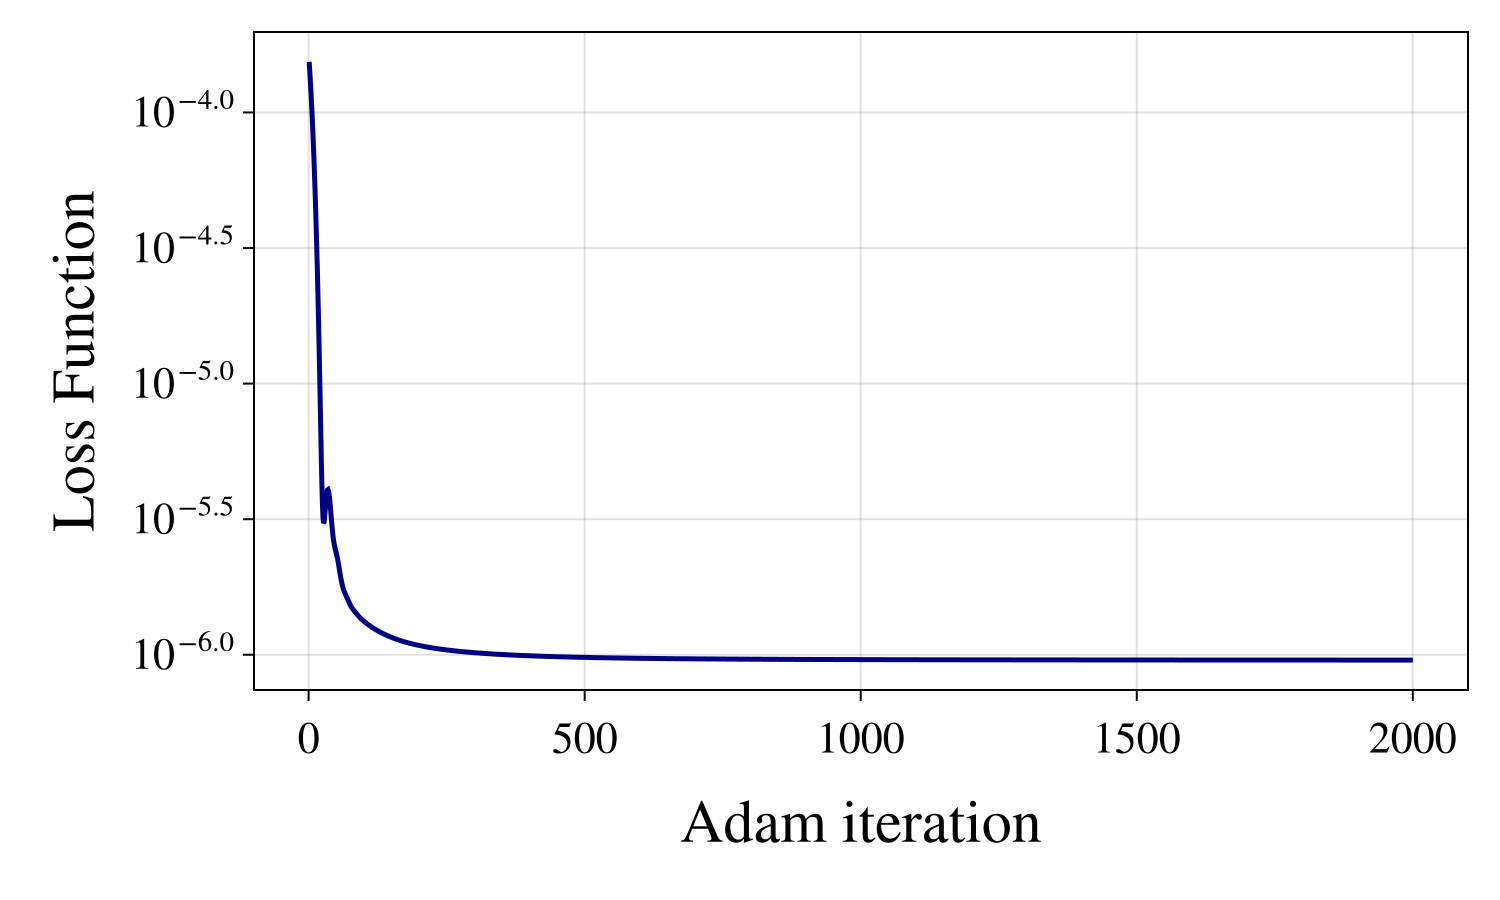

CairoMakie.Screen{IMAGE}


In [19]:
loss_figure = Figure(size=(750, 450))
loss_axis = Axis(
    loss_figure[1, 1];
    xlabel="Adam iteration",
    ylabel="Loss Function",
    yscale=log10,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
lines!(
    loss_axis,
    eachindex(result.loss_history),
    max.(result.loss_history, eps(Float64));
    color=:navy,
    linewidth=2.5,
)

display(loss_figure)

In [20]:
# ## Initial phase-space reconstruction in physical coordinates

function physical_grid_plot_data(grid, weights, machine)
    weight_matrix = grid_weight_matrix(grid, weights)
    delta_t_axis_ns = delta_t_from_theta(grid.theta_axis, machine) .* 1e9
    delta_E_axis_MeV = delta_energy_from_P(grid.P_axis, machine) .* 1e-6

    # eta0 < 0 makes Delta E decrease with normalized P. Sort the physical
    # energy axis before plotting and reorder the corresponding matrix rows.
    energy_order = sortperm(delta_E_axis_MeV)
    plot_matrix = permutedims(weight_matrix[energy_order, :])
    return delta_t_axis_ns, delta_E_axis_MeV[energy_order], plot_matrix
end

target_dt_ns, target_dE_MeV, target_matrix = physical_grid_plot_data(
    grid,
    target_weights,
    machine,
)
reconstructed_dt_ns, reconstructed_dE_MeV, reconstructed_matrix =
    physical_grid_plot_data(grid, reconstructed_weights, machine)
difference_matrix = reconstructed_matrix .- target_matrix

theta_separatrix = range(-pi, pi; length=1000)
P_separatrix = 2 .* cos.(theta_separatrix ./ 2)
delta_t_separatrix_ns = delta_t_from_theta(theta_separatrix, machine) .* 1e9
delta_E_separatrix_upper_MeV = delta_energy_from_P(
    P_separatrix,
    machine,
) .* 1e-6
delta_E_separatrix_lower_MeV = delta_energy_from_P(
    -P_separatrix,
    machine,
) .* 1e-6

1000-element Vector{Float64}:
 5.711584747872435e-16
 0.029333199623525544
 0.058666109160329646
 0.08799843852656078
 0.11732989764410437
 0.14666019644345202
 0.17598904486657024
 0.20531615286977076
 0.2346412304265709
 0.2639639875305738
 0.2932841341983287
 0.3226013804722
 0.3519154364232353
 ⋮
 0.3226013804722
 0.2932841341983287
 0.2639639875305738
 0.2346412304265709
 0.2053161528697687
 0.17598904486657024
 0.14666019644345202
 0.11732989764410437
 0.08799843852656078
 0.058666109160329646
 0.029333199623525544
 5.711584747872435e-16

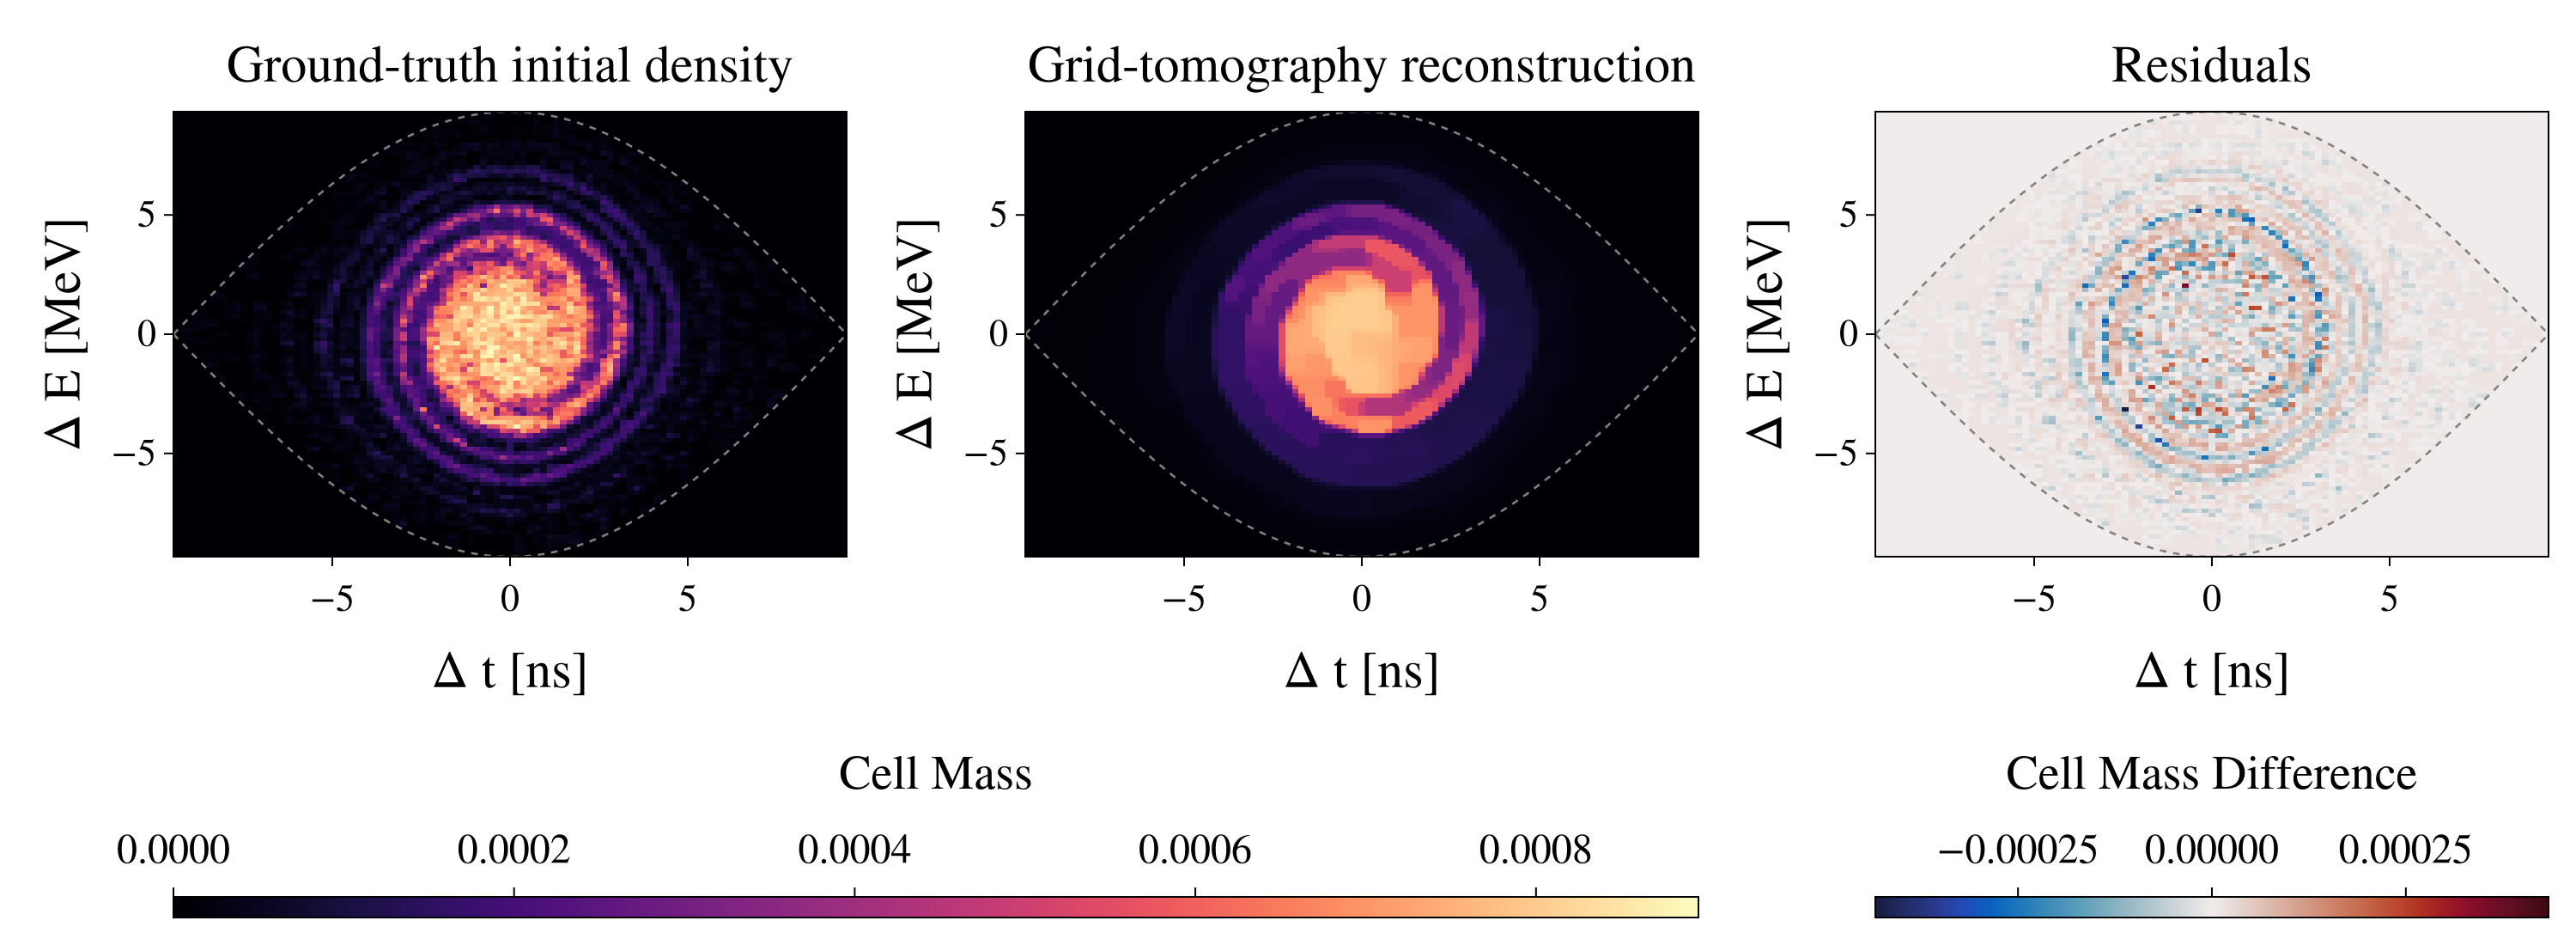

CairoMakie.Screen{IMAGE}


In [21]:

phase_figure = Figure(size=(1500, 550))
common_colorrange = (
    0.0,
    max(maximum(target_matrix), maximum(reconstructed_matrix)),
)
difference_limit = max(maximum(abs.(difference_matrix)), eps(Float64))

axis_target = Axis(
    phase_figure[1, 1];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="Ground-truth initial density",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
target_heatmap = heatmap!(
    axis_target,
    target_dt_ns,
    target_dE_MeV,
    target_matrix;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_reconstruction = Axis(
    phase_figure[1, 2];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="Grid-tomography reconstruction",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)

heatmap!(
    axis_reconstruction,
    reconstructed_dt_ns,
    reconstructed_dE_MeV,
    reconstructed_matrix;
    colormap=:magma,
    colorrange=common_colorrange,
)

axis_difference = Axis(
    phase_figure[1, 3];
    xlabel="Δ t [ns]",
    ylabel="Δ E [MeV]",
    title="Residuals",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
difference_heatmap = heatmap!(
    axis_difference,
    target_dt_ns,
    target_dE_MeV,
    difference_matrix;
    colormap=:balance,
    colorrange=(-difference_limit, difference_limit),
)

for axis in (axis_target, axis_reconstruction, axis_difference)
    lines!(
        axis,
        delta_t_separatrix_ns,
        delta_E_separatrix_upper_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )
    lines!(
        axis,
        delta_t_separatrix_ns,
        delta_E_separatrix_lower_MeV;
        color=:gray,
        linestyle=:dash,
        linewidth=1.3,
    )
end

Colorbar(phase_figure[2, 1:2], target_heatmap; vertical=false, label="Cell Mass",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
)
Colorbar(
    phase_figure[2, 3],
    difference_heatmap;
    vertical=false,
    label="Cell Mass Difference",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
)

display(phase_figure)

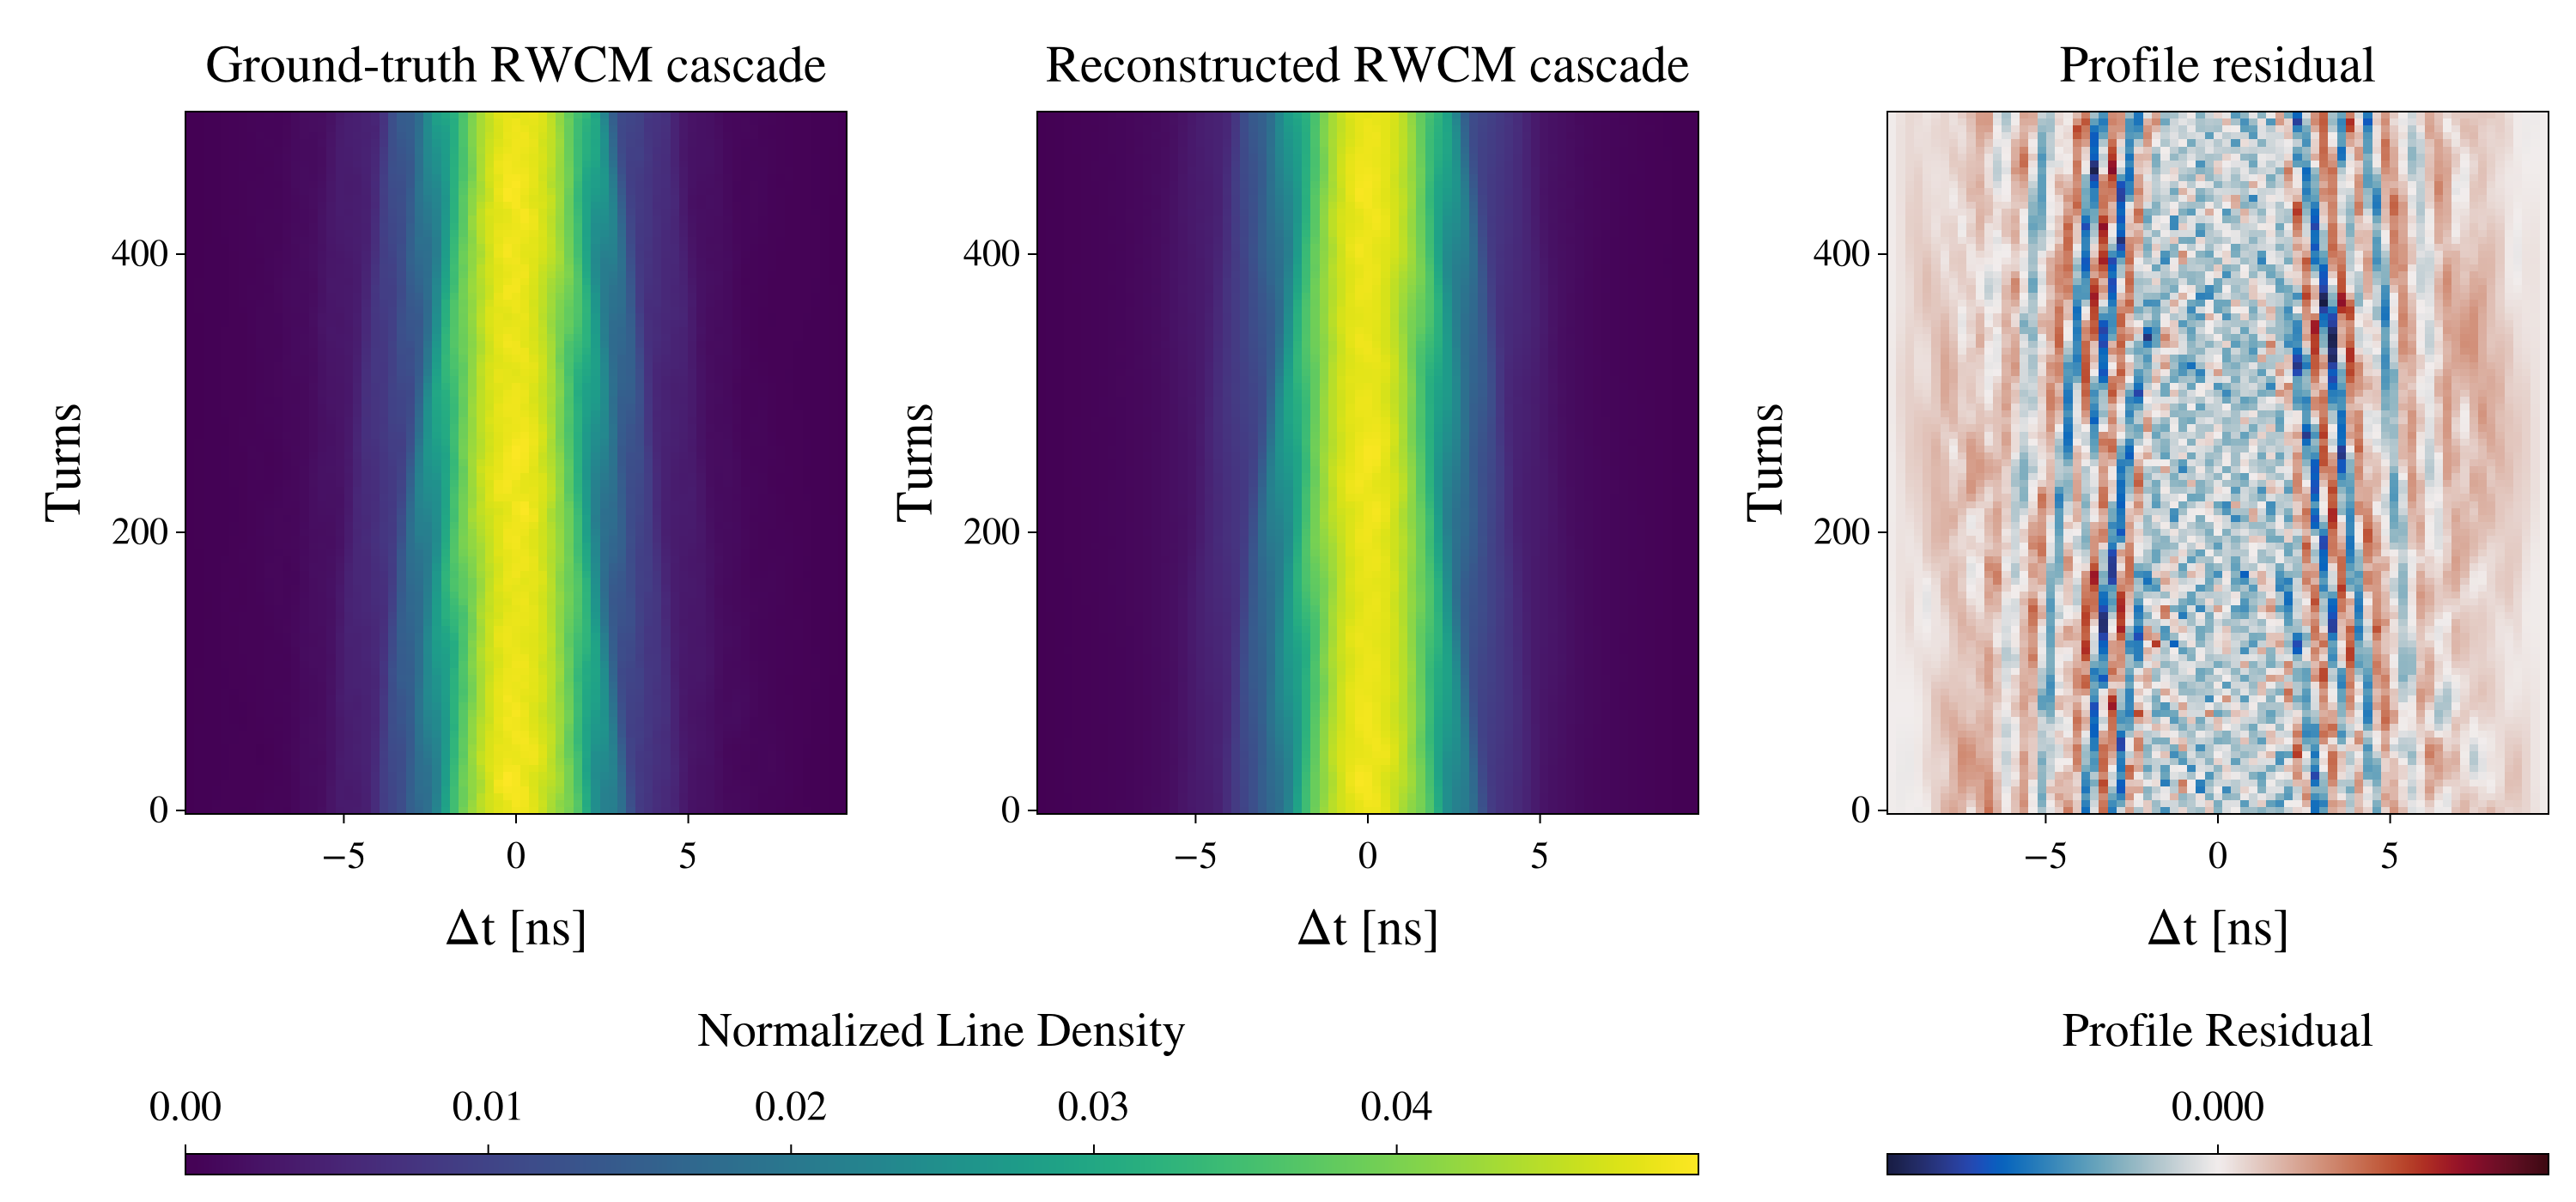

CairoMakie.Screen{IMAGE}


In [22]:
profile_residual = reconstructed_profiles .- target_profiles
profile_limit = max(maximum(target_profiles), maximum(reconstructed_profiles))
residual_limit = max(maximum(abs.(profile_residual)), eps(Float64))

cascade_figure = Figure(size=(1500, 700)) # Adjusted height slightly to 550 to match your reference layout math

axis_target_cascade = Axis(
    cascade_figure[1, 1];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Ground-truth RWCM cascade",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
target_cascade_heatmap = heatmap!(
    axis_target_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(target_profiles);
    colormap=:viridis,
    colorrange=(0, profile_limit),
)

axis_reconstructed_cascade = Axis(
    cascade_figure[1, 2];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Reconstructed RWCM cascade",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
heatmap!(
    axis_reconstructed_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(reconstructed_profiles);
    colormap=:viridis,
    colorrange=(0, profile_limit),
)

axis_residual_cascade = Axis(
    cascade_figure[1, 3];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Profile residual",
    titlefont = "StixGeneral",
    titlesize = 30,
    xlabelfont = "StixGeneral",
    ylabelfont = "StixGeneral",
    xlabelsize = 30,
    ylabelsize = 30,
    xticklabelfont = "StixGeneral",
    yticklabelfont = "StixGeneral",
    xticklabelsize = 22,
    yticklabelsize = 22,
)
residual_heatmap = heatmap!(
    axis_residual_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(profile_residual);
    colormap=:balance,
    colorrange=(-residual_limit, residual_limit),
)

Colorbar(
    cascade_figure[2, 1:2],
    target_cascade_heatmap;
    vertical=false,
    label="Normalized Line Density",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
)

Colorbar(
    cascade_figure[2, 3],
    residual_heatmap;
    vertical=false,
    label="Profile Residual",
    labelsize = 28,
    ticklabelsize = 24,
    ticklabelfont = "StixGeneral",
    labelfont = "StixGeneral",
    
    # Example: Manually setting ticks every 0.1 units from -0.5 to 0.5
    ticks = -0.005:0.001:0.005 
)


display(cascade_figure)


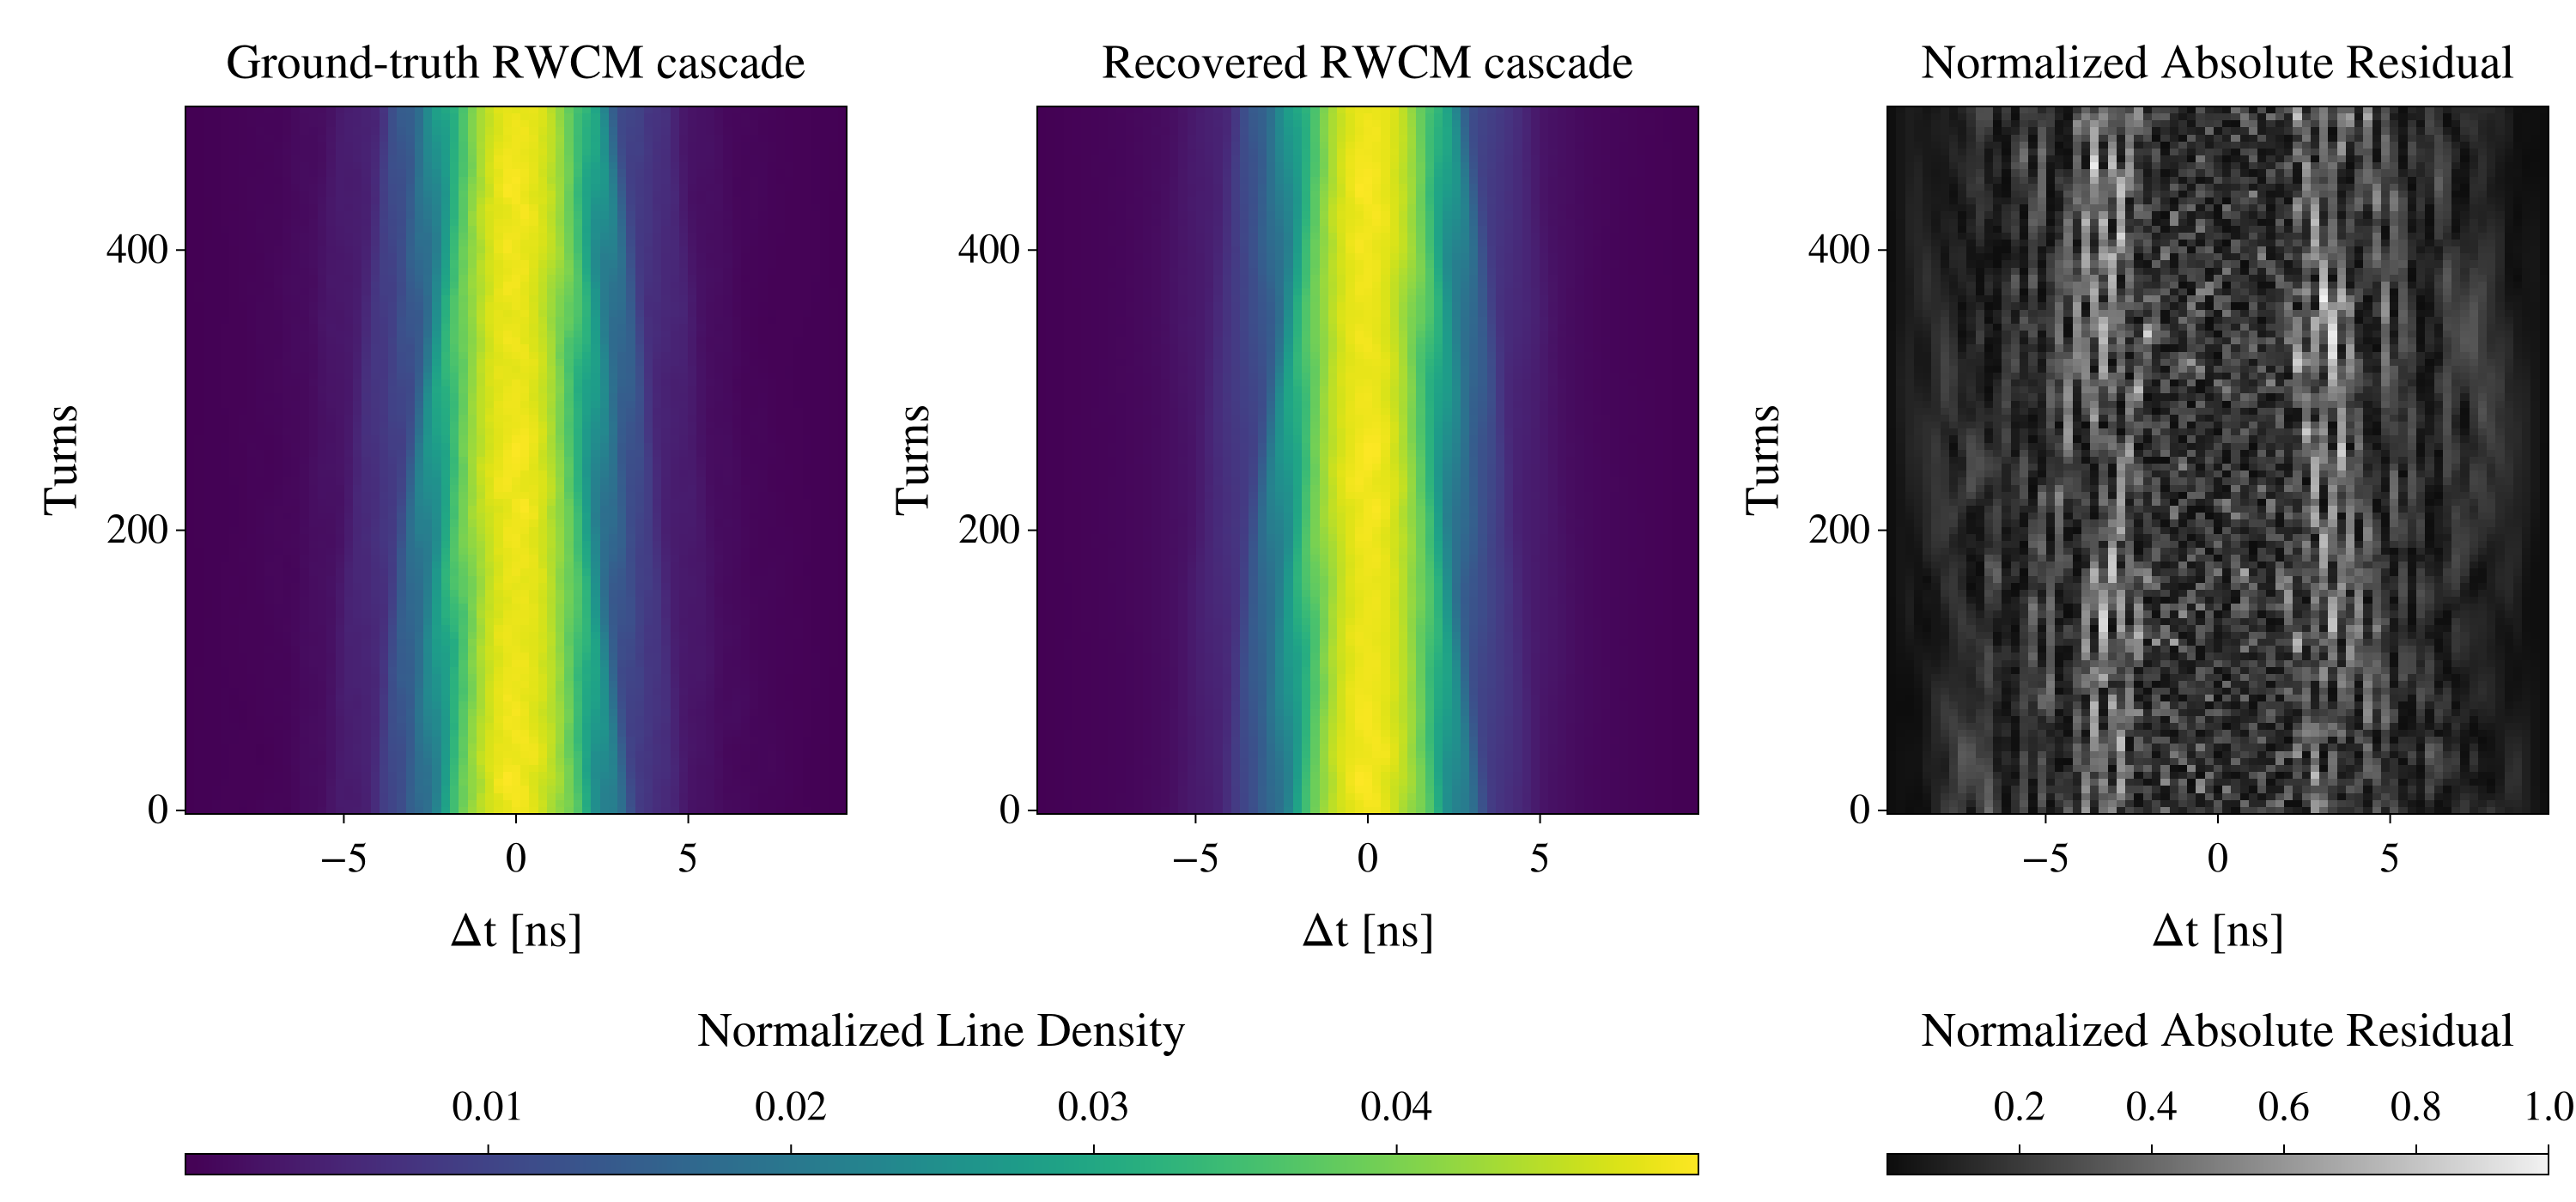

CairoMakie.Screen{IMAGE}


In [23]:
figure_profile_reco = Figure(size=(1500, 700))

target_axis = Axis(
    figure_profile_reco[1, 1];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title=title="Ground-truth RWCM cascade",
)

target_hm = heatmap!(
    target_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(target_profiles);
    colormap=:viridis,
)

Colorbar(figure_profile_reco[2, 1:2], target_hm,     labelsize = 28,
    ticklabelsize = 24, label = "Normalized Line Density",vertical=false)

prediction_axis = Axis(
    figure_profile_reco[1, 2];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Recovered RWCM cascade",
)

prediction_hm = heatmap!(
    prediction_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(reconstructed_profiles);
    colormap=:viridis,
    colorrange=(0, maximum(reconstructed_profiles)),
)

residual_axis = Axis(
    figure_profile_reco[1, 3];
    xlabel="Δt [ns]",
    ylabel="Turns",
    title="Normalized Absolute Residual",
)

residual_hm = heatmap!(
    residual_axis,
    response.time_bin_centers_s .* 1e9,
    response.turns,
    permutedims(abs.(target_profiles .- reconstructed_profiles)/maximum(abs.(target_profiles .- reconstructed_profiles)));
    colormap=:grays,
    #colorrange=(-maximum(abs.(target_profiles .- reconstructed_profiles)), maximum(abs.(target_profiles .- reconstructed_profiles))),
)

Colorbar(
    figure_profile_reco[2, 3],
    residual_hm;
    vertical=false,
    label="Normalized Absolute Residual",
    labelsize = 28,
    ticklabelsize = 24,
)

display(figure_profile_reco)